In [1]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [2]:
omics_d256 = pd.read_csv('../../../../../../../../s/project/gene_embedding/funcrvp_embeddings/omics_d256.tsv', sep='\t')
omics_d256


,gene_id,FACT_EMB_0,FACT_EMB_1,FACT_EMB_2,FACT_EMB_3,FACT_EMB_4,FACT_EMB_5,FACT_EMB_6,FACT_EMB_7,FACT_EMB_8,...,FACT_EMB_246,FACT_EMB_247,FACT_EMB_248,FACT_EMB_249,FACT_EMB_250,FACT_EMB_251,FACT_EMB_252,FACT_EMB_253,FACT_EMB_254,FACT_EMB_255
0,ENSG00000000003,-1.193790,-0.038485,0.477347,-1.355883,-1.283844,0.577406,-0.085741,-0.141601,0.929133,...,1.202038,-0.015473,0.732149,-0.470897,0.163932,0.514095,-1.121097,0.353111,-0.375309,0.271749
1,ENSG00000000005,-0.678243,-0.082044,0.628727,-0.036960,-0.327301,-0.132137,-0.658378,0.382881,0.321670,...,0.158936,1.025258,-0.944454,-0.110598,0.059320,-0.250677,-0.524779,-0.302290,0.627002,0.164144
2,ENSG00000000419,0.763473,0.029731,0.157848,-1.063333,-1.121445,0.855230,0.054342,0.782584,0.679390,...,0.215326,-0.662693,0.154820,0.359877,-0.675248,-0.293355,-0.355871,0.380746,-0.834603,-0.782095
3,ENSG00000000457,0.500445,0.107114,0.758035,-1.097068,0.355529,0.676653,0.562473,-0.585225,0.680695,...,-0.443879,0.226092,0.258948,0.716421,0.022804,-0.488464,-0.700852,-0.285765,0.137165,-0.220267
4,ENSG00000000460,0.085451,0.300662,-0.520867,-0.111104,0.116884,1.271965,0.750282,-0.769611,0.652003,...,-0.781987,-0.538280,-1.022490,-0.261985,-0.225361,0.223187,-0.840165,1.048801,-0.219930,-0.667091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19380,ENSG00000280178,0.151255,0.066157,0.085184,-0.053143,-0.270811,0.211693,-0.401942,0.048608,0.396584,...,0.036106,0.029502,-0.247412,-0.039378,-0.355921,-0.143174,-0.001159,0.033741,-0.136875,-0.467921
19381,ENSG00000280253,0.139209,0.173939,-0.025301,0.197056,-0.086932,0.248732,-0.317894,0.000547,0.264560,...,0.139947,-0.031823,-0.109894,0.097934,-0.243768,-0.176109,-0.002984,-0.027844,0.069011,-0.645361
19382,ENSG00000280267,-0.799880,-0.290801,0.281187,-0.347249,-0.004650,0.019152,0.336727,0.289013,-0.390199,...,-0.213539,-0.293435,-0.636833,0.811885,-0.119030,0.375083,0.600217,-0.772333,0.670361,-0.510163
19383,ENSG00000280297,0.125944,0.020628,-0.069116,-0.076246,-0.322970,0.216778,-0.389412,0.208437,0.143095,...,-0.069501,0.155821,-0.123458,0.270595,-0.460678,0.027504,0.098230,-0.058452,0.088184,-0.454670


In [3]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [4]:
NCG_Known_Genes = emogi_predictions[['ID', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = omics_d256.merge(NCG_Known_Genes, left_on="gene_id" ,right_on='ID', how='inner').drop(columns=['ID'])
merged.set_index('gene_id', inplace=True)
merged

,FACT_EMB_0,FACT_EMB_1,FACT_EMB_2,FACT_EMB_3,FACT_EMB_4,FACT_EMB_5,FACT_EMB_6,FACT_EMB_7,FACT_EMB_8,FACT_EMB_9,...,FACT_EMB_250,FACT_EMB_251,FACT_EMB_252,FACT_EMB_253,FACT_EMB_254,FACT_EMB_255,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,-1.193790,-0.038485,0.477347,-1.355883,-1.283844,0.577406,-0.085741,-0.141601,0.929133,1.186045,...,0.163932,0.514095,-1.121097,0.353111,-0.375309,0.271749,False,False,False,False
ENSG00000000005,-0.678243,-0.082044,0.628727,-0.036960,-0.327301,-0.132137,-0.658378,0.382881,0.321670,0.529753,...,0.059320,-0.250677,-0.524779,-0.302290,0.627002,0.164144,False,False,False,False
ENSG00000000419,0.763473,0.029731,0.157848,-1.063333,-1.121445,0.855230,0.054342,0.782584,0.679390,1.211714,...,-0.675248,-0.293355,-0.355871,0.380746,-0.834603,-0.782095,False,False,False,False
ENSG00000000457,0.500445,0.107114,0.758035,-1.097068,0.355529,0.676653,0.562473,-0.585225,0.680695,0.630335,...,0.022804,-0.488464,-0.700852,-0.285765,0.137165,-0.220267,False,False,False,False
ENSG00000000938,0.028955,-1.648038,-0.350896,-0.627108,-0.550959,-0.247590,-0.696156,1.024084,-0.360113,0.243453,...,0.394716,-1.287675,1.218878,0.090639,0.014660,-0.058914,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000278129,0.229655,-0.531013,0.402786,-0.342882,0.224981,0.286429,1.192782,-0.521401,-0.675146,0.123290,...,-1.356480,-0.635546,0.356981,-0.218954,-0.022984,-0.940951,False,False,False,False
ENSG00000278195,-0.623717,0.067353,-0.356791,-0.098031,-0.920190,-0.706171,0.113246,0.265221,-0.194234,0.195562,...,-1.339204,-0.385016,-0.871387,-0.447856,0.137343,-1.632446,False,False,False,False
ENSG00000278259,-0.337752,1.050343,-0.427946,0.061386,0.829865,0.517667,1.378347,-1.363788,0.969981,0.488213,...,-0.463258,-0.084713,-0.884232,-0.142783,0.533993,0.507655,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [5]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    12315
True       629
Name: count, dtype: int64

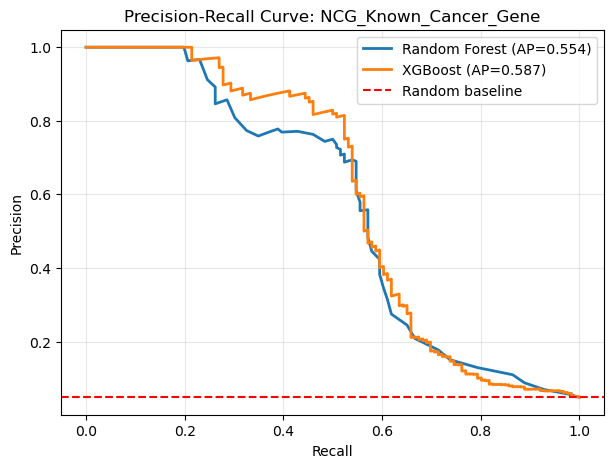

Random Forest - auPRC: 0.554
XGBoost - auPRC: 0.587



In [6]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [7]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    11726
True      1218
Name: count, dtype: int64

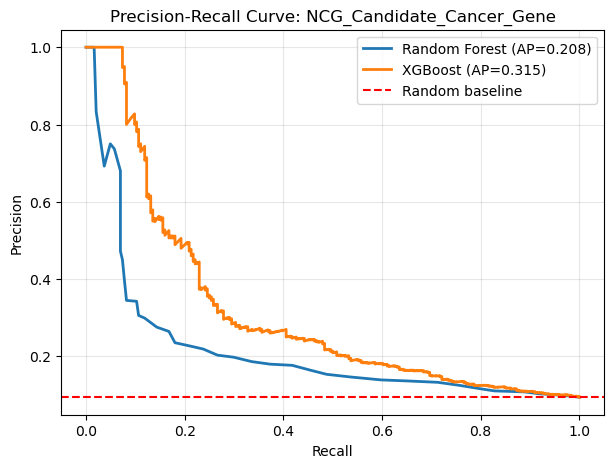

Random Forest - auPRC: 0.208
XGBoost - auPRC: 0.315



In [8]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [9]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    12448
True       496
Name: count, dtype: int64

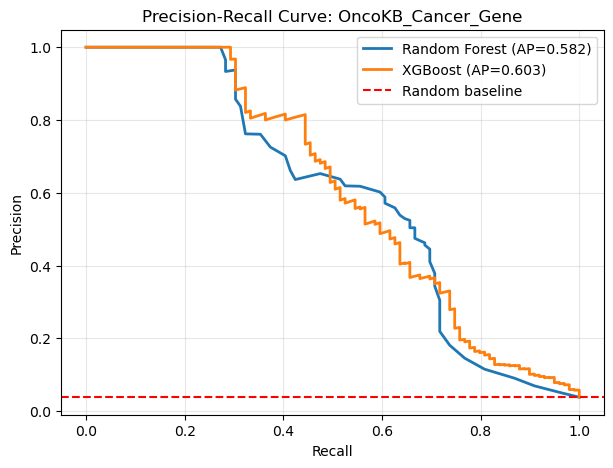

Random Forest - auPRC: 0.582
XGBoost - auPRC: 0.603



In [10]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [11]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    12676
True       268
Name: count, dtype: int64

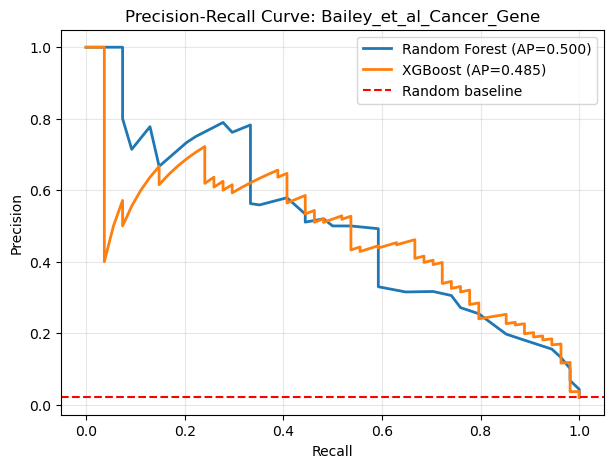

Random Forest - auPRC: 0.500
XGBoost - auPRC: 0.485



In [12]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')